### Imports and downloading data

In [27]:
import torch
from torch.nn import CrossEntropyLoss
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

train_data = datasets.FashionMNIST(root='data', train=True, download=True, transform=ToTensor())
test_data = datasets.FashionMNIST(root='data', train=False, download=True, transform=ToTensor())

img1, label1 = train_data[0]
img2, label2 = test_data[1]
img1.shape

100.0%
100.0%
100.0%
100.0%


torch.Size([1, 28, 28])

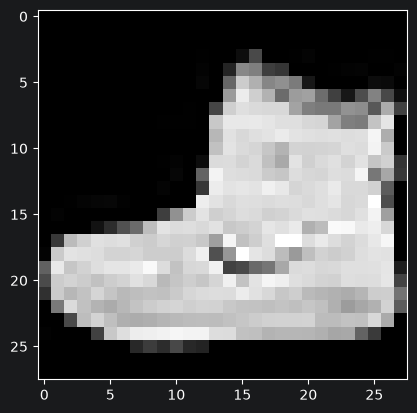

In [28]:
plt.imshow(img1.squeeze(), cmap='gray')

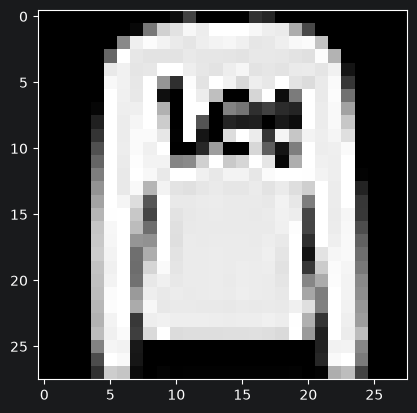

In [29]:
plt.imshow(img2.squeeze(), cmap='gray')

In [30]:
len(train_data)

60000

### Dataloaders

In [31]:
train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=False)

### NNModule

In [32]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

### Training loop

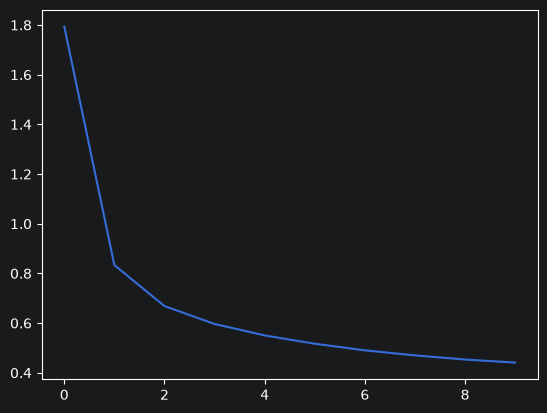

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Model().to(device)

criterion = CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)
loss_history = []
model.train()
for epoch in range(10):
    running_loss = 0
    for X, y in train_dataloader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        loss = criterion(logits, y)
        running_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    loss_history.append(running_loss / len(train_dataloader))

plt.plot(loss_history)

### Model evaluation

In [34]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        predictions = logits.argmax(dim=1)
        correct += (predictions == y).sum().item()
        total += len(y)

(correct / total) * 100

83.43